### Libraries and Imports

In [72]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(
    0,
    str(Path("../../build-release").resolve())
)

import mpcd_cpp

print(mpcd_cpp.__file__)

/Users/olegoniy/Desktop/MPCD/build-release/mpcd_cpp.cpython-39-darwin.so


In [73]:
polymer = mpcd_cpp.Polymer(
    25,                               # n_monomers
    np.array([10.0, 10.0, 10.0]),     # box
    1e-4,                             # dt
    0.5,                              # bond length
    4,                                # mass
    100.0,                            # k
    1.0,                              # kBT
    42                                # seed
)


### Genaration of a Polymer (__Linear__)

Rel. distnces between monomers:[0.9833708611518656, 0.9642866814416167, 1.015088847342602, 0.9556411576462123, 1.0221998771645577, 1.0438552714379608, 0.9500778764768584, 1.0492211564253513, 1.0117481507403652, 1.0111653162470138, 0.9507066308642912, 0.9523062428560092, 1.0024774661821139, 0.9899860977803313, 0.9546665668287198, 1.0473755522466306, 0.9732771340377256, 0.9590606435541078, 1.0118386014780303, 0.9882461990043435, 1.0483230885936476, 0.9966762898627766, 1.0359940403151897, 1.0180307538855717]


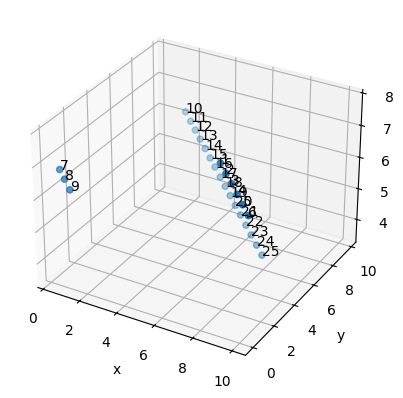

In [74]:
polymer.initPositionsLinear()

#print(f"Positions of monomers:{polymer.r}\n")
print(f"Rel. distnces between monomers:{[ polymer.distancePBC(i, i+1)/polymer.r0 for i in range(0, polymer.N-1)]}") 

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    polymer.r[:, 0],
    polymer.r[:, 1],
    polymer.r[:, 2]
)
for i in range(len(polymer.r)):
    ax.text(polymer.r[i, 0], polymer.r[i, 1], polymer.r[i, 2], str(i+1))

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

Rel. distnces between monomers:[1.0109996656682814, 1.0255361408847974, 1.0342284773003676, 0.9826540771620773, 1.0086751168553882, 0.9665266941488301, 0.9514079823625634, 1.0426300877955281, 0.9595410116093914, 0.9774721791417699, 0.9756068322288557, 0.9975370224713439, 1.0039841089027546, 0.9795633688058742, 1.038328026186036, 0.9772132247712015, 0.9984829976553421, 0.971876422300078, 0.9746876063747908, 0.9845071248542213, 1.0052893088661525, 1.0303139754973405, 1.0298345122274537, 0.9825958906577629]


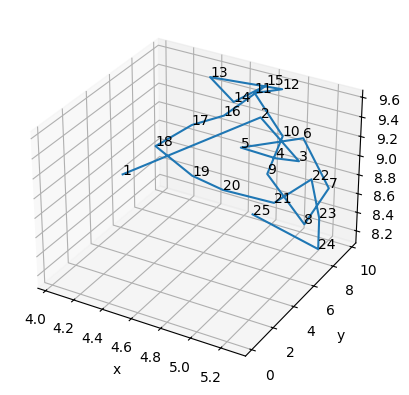

In [75]:
polymer.initPositionsRandomWalk()

#print(f"Positions of monomers:{polymer.r}\n")
print(f"Rel. distnces between monomers:{[ polymer.distancePBC(i, i+1)/polymer.r0 for i in range(0, polymer.N-1)]}") 

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    polymer.r[:, 0],
    polymer.r[:, 1],
    polymer.r[:, 2]
)
for i in range(len(polymer.r)):
    ax.text(polymer.r[i, 0], polymer.r[i, 1], polymer.r[i, 2], str(i+1))

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

In [76]:
def average_length(polymer):
    return np.asarray(mpcd_cpp.polymerBondLengths(polymer)).mean()


In [77]:
samples = mpcd_cpp.runPolymer(
    polymer,
    300_000,   # total MD steps
    1,         # sample observables every step
    5,         # save polymer frame every 5 steps
    10
)


In [78]:
steps = np.asarray(samples.steps)
average = np.asarray(samples.averageBondLength)
absolute_length = np.asarray(samples.endToEndDistance)
frame_steps = np.asarray(samples.frameSteps)
polymer_frames = np.asarray(samples.frames)

Shortest average: 0.49476956714998405/nLongest average0.5056146172504236/nDifference: 0.010845050100439513


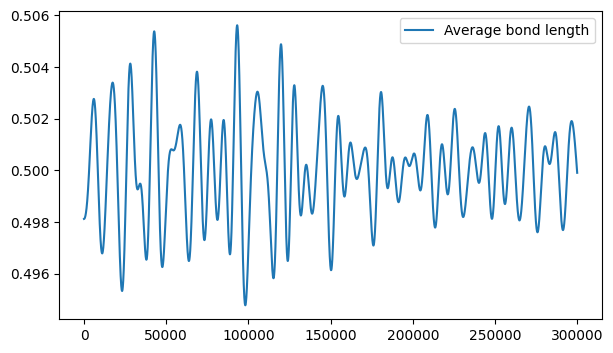

In [79]:
print(f"Shortest average: {average.min()}/nLongest average{average.max()}/nDifference: {average.max() - average.min()}")

plt.figure(figsize=(7, 4))
plt.plot(average, label="Average bond length")
plt.legend()
plt.show()


## Absolute polymer length

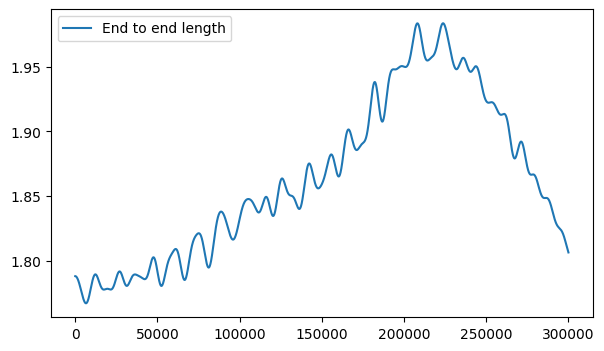

In [80]:
plt.figure(figsize=(7, 4))
plt.plot(absolute_length, label="End to end length")
plt.legend()
plt.show()

In [81]:
polymer.initPositionsRandomWalk()
polymer.initVelocitiesNormal()

In [82]:
samples = mpcd_cpp.runPolymer(
    polymer,
    300_000,
    1,      # energies every step
    0,      # no full polymer frames
    10      # bond vectors every 10 steps
)



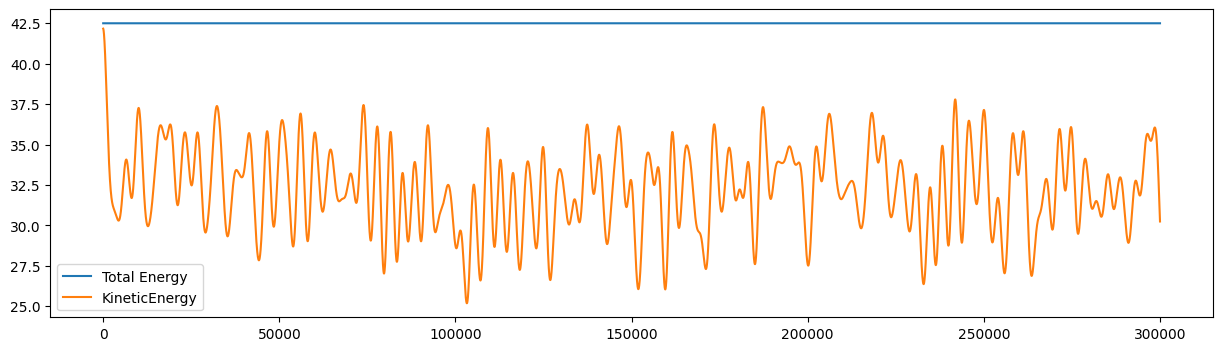

In [83]:
energy = np.asarray(samples.totalEnergy)
k_energy = np.asarray(samples.kineticEnergy)

b = np.asarray(samples.bondVectors)
bond_vector_steps = np.asarray(samples.bondVectorSteps)

plt.figure(figsize=(15, 4))
plt.plot(energy, label='Total Energy')
plt.plot(k_energy, label='KineticEnergy')
plt.legend()
plt.show()

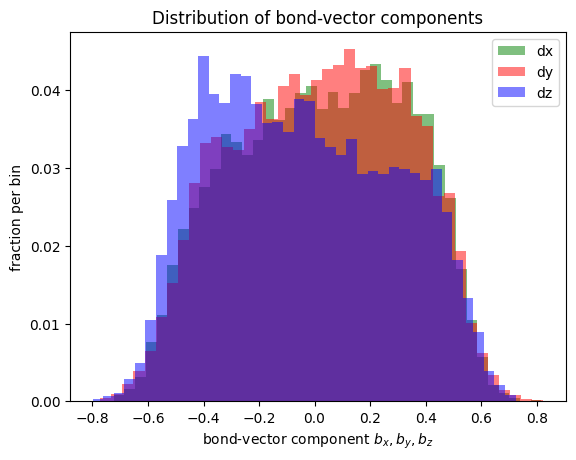

In [84]:
bond_length_history = np.linalg.norm(b, axis=2)
lengths_all = bond_length_history.ravel()
weights = np.ones_like(lengths_all) / len(lengths_all)

plt.figure()
plt.hist(b[:, :, 0].ravel(), bins=40, weights=weights, alpha=0.5, label="dx", color="green")
plt.hist(b[:, :, 1].ravel(), bins=40, weights=weights, alpha=0.5, label="dy", color="red")
plt.hist(b[:, :, 2].ravel(), bins=40, weights=weights, alpha=0.5, label="dz", color="blue")
plt.xlabel(r"bond-vector component $b_x, b_y, b_z$")
plt.ylabel("fraction per bin")
plt.title("Distribution of bond-vector components")
plt.legend()
plt.show()

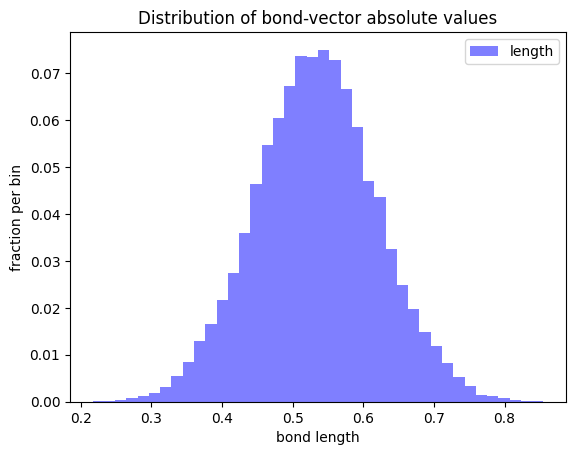

In [85]:
plt.figure()
plt.hist(lengths_all, bins=40, weights=weights, alpha=0.5, label="length", color="blue")
plt.title("Distribution of bond-vector absolute values")
plt.xlabel("bond length")
plt.ylabel("fraction per bin")
plt.legend()
plt.show()